# Community Assignment EDA (from Task 4 output)

## Objective
Analyze graph-based station community assignments generated in Task 4, summarize the output data, visualize spatial patterns, and produce cluster-level forecasting diagnostics.

## Forecasting Recommendation
Use **cluster `51539607555`** first for scoped forecasting under constrained compute.

### Why this cluster
- Large enough (`123` stations) to retain cross-station learning signal.
- High volume (`~3.22M` outbound, `~3.87M` inbound rides) for robust model training.
- Better cohesion than the largest cluster (`internal_outbound_share ~ 0.647`), which reduces cross-cluster mixing noise.

## How To Retrieve Data For This Recommendation
1. Read rides from `data/silver/rides`.
2. Read community assignments from `data/features_temp/community_assignments`.
3. Join assignments to both `start_canonical_station_id` and `end_canonical_station_id`.
4. Aggregate per cluster and filter to `cluster_id == 51539607555`.

Example query flow (implemented below in Task 4):
- Build `cluster_enriched_stats` for all clusters.
- Select target cluster: `cluster_enriched_stats.filter(F.col("cluster_id") == 51539607555)`.

## Plan
1. Read `community_assignments` and summarize community size distribution.
2. Join communities with station coordinates and map top-10 communities.
3. Add extra spatial diagnostics (centroids and spread).
4. Build enriched per-cluster ride-flow statistics from rides + persisted assignments.

## Notes
- Local Spark mode, Databricks-compatible transformations.
- Coordinates are sourced from `data/silver/station_cleaning/station_direct_match_mapping`.
- Dedup guards are included for station-to-community and station-to-coordinate joins.

In [12]:
# Task 1: Setup shared paths, load persisted community assignments, and build base summaries.
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("bixi-community-eda")
    .master("local[*]")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.shuffle.partitions", "96")
    .getOrCreate()
)
spark.conf.set("spark.sql.session.timeZone", "America/Toronto")

BASE_DIR = Path("data")
RIDES_PATH = BASE_DIR / "silver" / "rides"
COMMUNITY_ASSIGNMENTS_PATH = BASE_DIR / "features_temp" / "community_assignments"
COORD_PATH = BASE_DIR / "silver" / "station_cleaning" / "station_direct_match_mapping"

for p in [RIDES_PATH, COMMUNITY_ASSIGNMENTS_PATH, COORD_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required path: {p}")

communities_sdf = spark.read.parquet(str(COMMUNITY_ASSIGNMENTS_PATH))
required_assignment_cols = {"id", "label"}
missing_assignment_cols = required_assignment_cols.difference(set(communities_sdf.columns))
if missing_assignment_cols:
    raise ValueError(f"community assignments missing required columns: {sorted(missing_assignment_cols)}")

community_sizes_sdf = (
    communities_sdf
    .groupBy("label")
    .agg(F.count("*").alias("station_count"))
    .orderBy(F.desc("station_count"), F.col("label"))
)

overview = community_sizes_sdf.select(
    F.count("*").alias("n_communities"),
    F.sum("station_count").alias("n_stations"),
    F.max("station_count").alias("largest_community"),
).first()

top10_communities_pdf = community_sizes_sdf.limit(10).toPandas()
top10_labels = [int(v) for v in top10_communities_pdf["label"].tolist()]

print("Loaded community assignments from:", COMMUNITY_ASSIGNMENTS_PATH)
print("Overview:", dict(overview.asDict()))
print("Top 10 communities by station count:")
display(top10_communities_pdf)

Loaded community assignments from: data/features_temp/community_assignments
Overview: {'n_communities': 39, 'n_stations': 1133, 'largest_community': 162}
Top 10 communities by station count:


,label,station_count
0,0,162
1,51539607555,123
2,25769803777,108
3,68719476737,88
4,8589934592,71
5,8589934595,70
6,25769803780,65
7,25769803776,64
8,4,54
9,51539607558,51


Coordinate source used: data/silver/station_cleaning/station_direct_match_mapping
Coordinate rows/distinct station ids: 1421 1421
Top-10 station-community rows/distinct keys: 856 856
Coordinate coverage for top-10 communities: {'stations_top10': 856, 'stations_with_coords': 856}


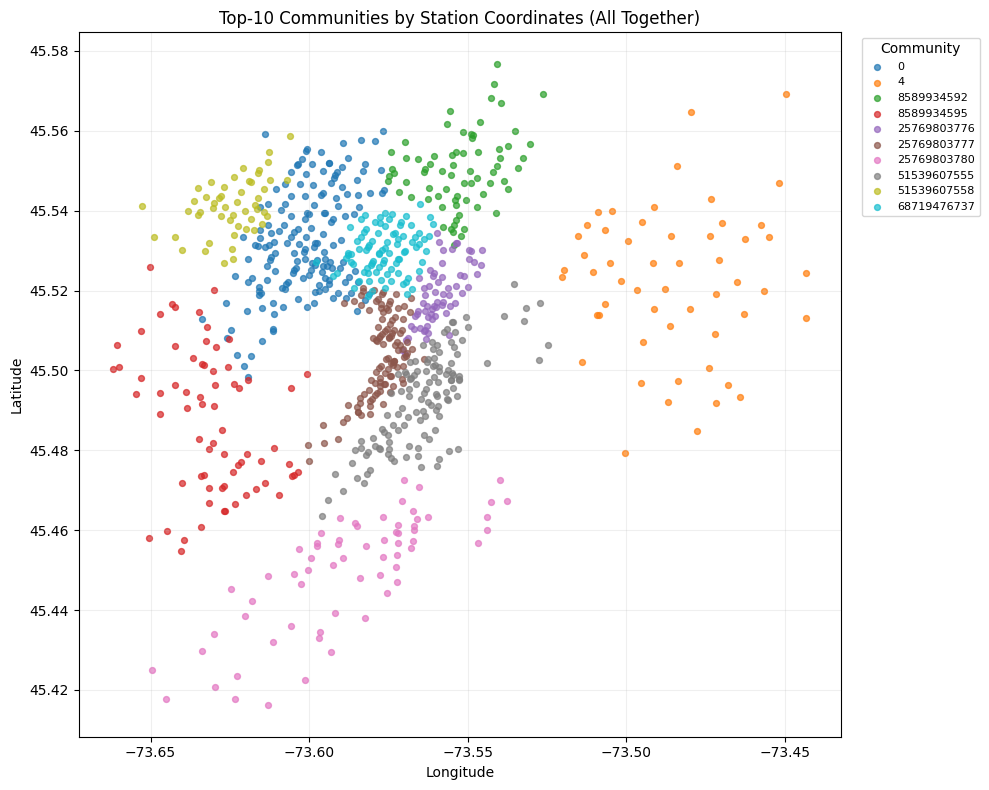

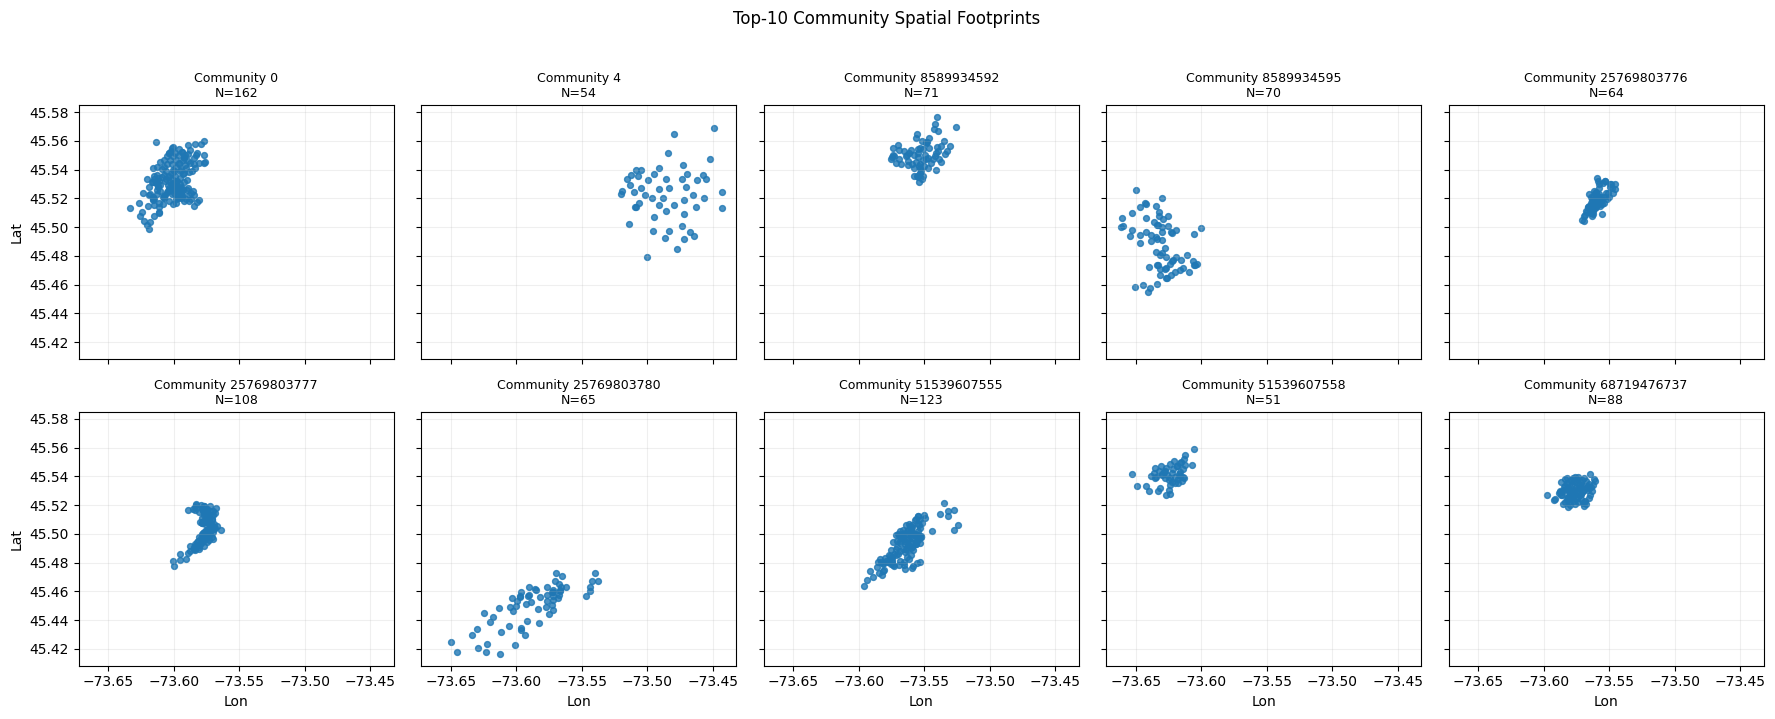

In [13]:
# Task 2: Join top-10 communities with station coordinates and map them.
coord_raw_sdf = spark.read.parquet(str(COORD_PATH))
required_coord_cols = ["canonical_station_id", "canonical_lat", "canonical_lon"]
missing_coord_cols = [c for c in required_coord_cols if c not in coord_raw_sdf.columns]
if missing_coord_cols:
    raise ValueError(f"Coordinate table missing required columns: {missing_coord_cols}")

coord_sdf = (
    coord_raw_sdf
    .select(
        F.col("canonical_station_id"),
        F.col("canonical_lat").cast("double").alias("latitude"),
        F.col("canonical_lon").cast("double").alias("longitude"),
    )
    .where(F.col("canonical_station_id").isNotNull())
    .where(F.col("latitude").isNotNull() & F.col("longitude").isNotNull())
    .groupBy("canonical_station_id")
    .agg(
        F.avg("latitude").alias("latitude"),
        F.avg("longitude").alias("longitude"),
    )
)

top10_labels_sdf = spark.createDataFrame([(int(v),) for v in top10_labels], ["label"] )
top10_communities_sdf = (
    communities_sdf
    .join(top10_labels_sdf, on="label", how="inner")
    .select(F.col("id").alias("canonical_station_id"), "label")
    .dropDuplicates(["canonical_station_id", "label"])
)

top10_coords_sdf = top10_communities_sdf.join(coord_sdf, on="canonical_station_id", how="left")

coord_key_rows = coord_sdf.count()
coord_key_distinct = coord_sdf.select("canonical_station_id").distinct().count()
community_key_rows = top10_communities_sdf.count()
community_key_distinct = top10_communities_sdf.select("canonical_station_id", "label").distinct().count()

if coord_key_rows != coord_key_distinct:
    raise ValueError("Coordinate table still has duplicate canonical_station_id after dedup")
if community_key_rows != community_key_distinct:
    raise ValueError("Top-10 community station keys are duplicated")

coverage_stats = top10_coords_sdf.select(
    F.count("*").alias("stations_top10"),
    F.count(F.when(F.col("latitude").isNotNull() & F.col("longitude").isNotNull(), 1)).alias("stations_with_coords"),
).first()

top10_coords_pdf = (
    top10_coords_sdf
    .where(F.col("latitude").isNotNull() & F.col("longitude").isNotNull())
    .toPandas()
)

if top10_coords_pdf.empty:
    raise ValueError("Top-10 communities have no usable coordinates")

print("Coordinate source used:", COORD_PATH)
print("Coordinate rows/distinct station ids:", coord_key_rows, coord_key_distinct)
print("Top-10 station-community rows/distinct keys:", community_key_rows, community_key_distinct)
print("Coordinate coverage for top-10 communities:", dict(coverage_stats.asDict()))

plt.figure(figsize=(10, 8))
for label, grp in top10_coords_pdf.groupby("label"):
    plt.scatter(grp["longitude"], grp["latitude"], s=18, alpha=0.70, label=str(label))
plt.title("Top-10 Communities by Station Coordinates (All Together)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Community", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

labels_sorted = sorted(top10_coords_pdf["label"].unique().tolist())
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
for ax, label in zip(axes.flat, labels_sorted):
    g = top10_coords_pdf[top10_coords_pdf["label"] == label]
    ax.scatter(g["longitude"], g["latitude"], s=18, alpha=0.8)
    ax.set_title(f"Community {label}\nN={len(g)}", fontsize=9)
    ax.grid(alpha=0.2)
for ax in axes[1, :]:
    ax.set_xlabel("Lon")
for ax in axes[:, 0]:
    ax.set_ylabel("Lat")
fig.suptitle("Top-10 Community Spatial Footprints", y=1.02)
plt.tight_layout()
plt.show()

,label,station_count,centroid_lat,centroid_lon,mean_radius_km,p90_radius_km,max_radius_km
0,0,162,45.532120,-73.601155,1.531362,2.586668,3.997746
7,51539607555,123,45.492966,-73.563904,1.408869,2.706017,4.089038
5,25769803777,108,45.503848,-73.577504,1.080700,1.748414,3.414717
9,68719476737,88,45.529843,-73.576283,0.785292,1.240369,1.716091
2,8589934592,71,45.550027,-73.552593,1.229783,1.804890,3.086488
3,8589934595,70,45.487452,-73.631151,2.020437,3.243861,4.498346
6,25769803780,65,45.449782,-73.587807,2.192726,4.212236,5.712046
4,25769803776,64,45.518867,-73.559136,0.833132,1.478356,1.836195
1,4,54,45.522247,-73.485281,2.352659,3.557590,5.897858
8,51539607558,51,45.541178,-73.624500,0.946597,1.632932,2.424109


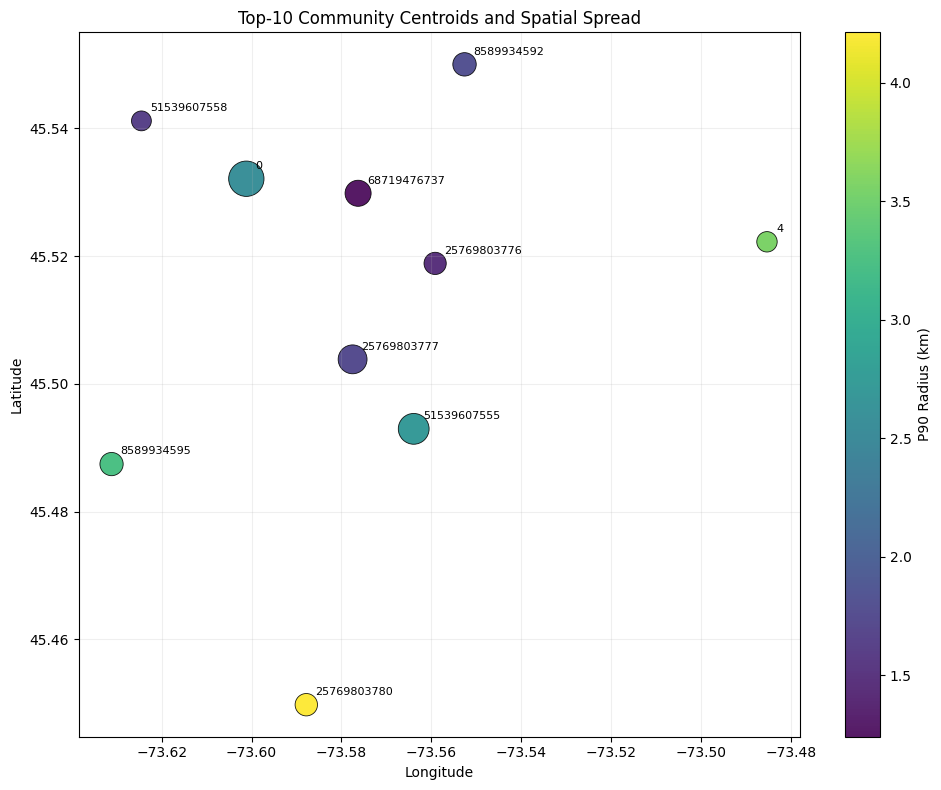

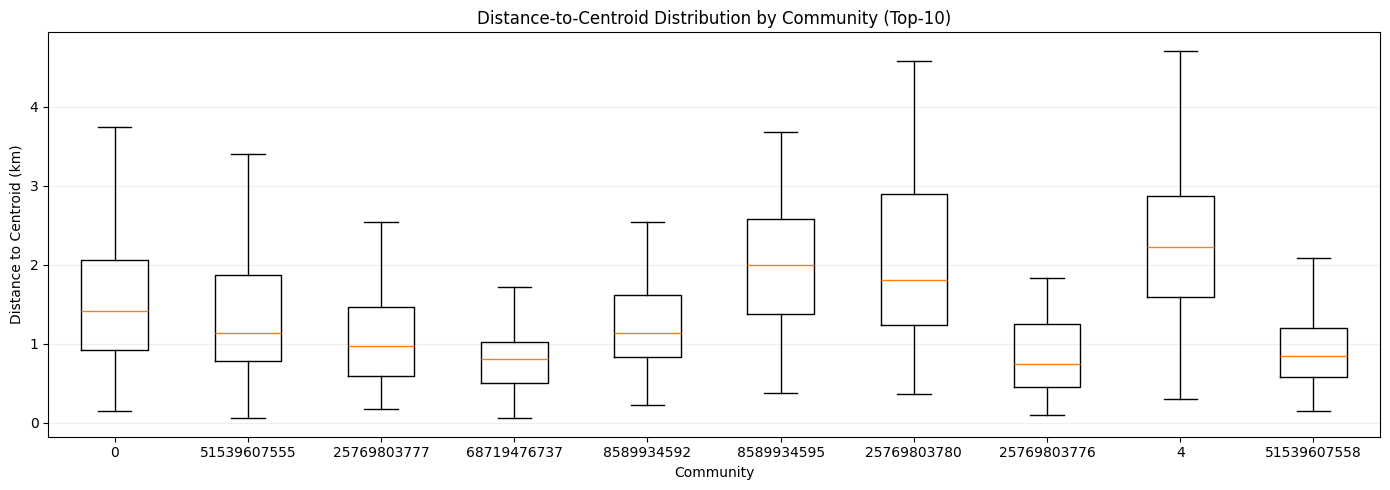

Task 3 complete: generated centroid/spread table and two additional spatial diagnostics.


In [14]:
# Task 3: Additional spatial diagnostics for top-10 communities.
if "top10_coords_pdf" not in globals() or top10_coords_pdf.empty:
    raise ValueError("Task 2 output not found. Run Task 2 first.")

def distance_to_centroid_km(df):
    lat_c = df["latitude"].mean()
    lon_c = df["longitude"].mean()
    dx_km = (df["longitude"] - lon_c) * 111.32 * np.cos(np.deg2rad(lat_c))
    dy_km = (df["latitude"] - lat_c) * 110.57
    dist_km = np.sqrt(dx_km**2 + dy_km**2)
    return lat_c, lon_c, dist_km

metrics_rows = []
distance_rows = []
for label, grp in top10_coords_pdf.groupby("label"):
    lat_c, lon_c, dist_km = distance_to_centroid_km(grp)
    metrics_rows.append({
        "label": int(label),
        "station_count": int(len(grp)),
        "centroid_lat": float(lat_c),
        "centroid_lon": float(lon_c),
        "mean_radius_km": float(dist_km.mean()),
        "p90_radius_km": float(np.percentile(dist_km, 90)),
        "max_radius_km": float(dist_km.max()),
    })
    for d in dist_km.values:
        distance_rows.append({"label": int(label), "distance_km": float(d)})

community_metrics_pdf = pd.DataFrame(metrics_rows).sort_values("station_count", ascending=False)
distance_pdf = pd.DataFrame(distance_rows)
display(community_metrics_pdf)

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    community_metrics_pdf["centroid_lon"],
    community_metrics_pdf["centroid_lat"],
    s=community_metrics_pdf["station_count"] * 4,
    c=community_metrics_pdf["p90_radius_km"],
    cmap="viridis",
    alpha=0.9,
    edgecolors="black",
    linewidths=0.6,
 )
for _, r in community_metrics_pdf.iterrows():
    plt.text(r["centroid_lon"] + 0.002, r["centroid_lat"] + 0.0015, str(int(r["label"])), fontsize=8)
plt.colorbar(sc, label="P90 Radius (km)")
plt.title("Top-10 Community Centroids and Spatial Spread")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

labels_order = community_metrics_pdf.sort_values("station_count", ascending=False)["label"].tolist()
box_data = [distance_pdf.loc[distance_pdf["label"] == lbl, "distance_km"].values for lbl in labels_order]

plt.figure(figsize=(14, 5))
plt.boxplot(box_data, tick_labels=[str(x) for x in labels_order], showfliers=False)
plt.title("Distance-to-Centroid Distribution by Community (Top-10)")
plt.xlabel("Community")
plt.ylabel("Distance to Centroid (km)")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("Task 3 complete: generated centroid/spread table and two additional spatial diagnostics.")

## Cluster-Level Enriched Stats From Persisted Assignments

### Objective
Build additional per-cluster columns using persisted community assignments and silver rides data.

### Plan
1. Read `data/features_temp/community_assignments` and enforce one cluster label per station.
2. Join assignments to rides on both start/end station IDs.
3. Compute enriched cluster metrics: station count, inbound/outbound, internal/cross shares, net flow, and connectivity breadth.

In [15]:
# Task 4: Build enriched per-cluster stats from persisted assignments + rides.
rides_all = spark.read.parquet(str(RIDES_PATH))

# Reuse validated assignments from Task 1 instead of re-reading and re-validating.
cluster_map = (
    communities_sdf
    .select(F.col("id").alias("canonical_station_id"), F.col("label").alias("cluster_id"))
    .where(F.col("canonical_station_id").isNotNull() & F.col("cluster_id").isNotNull())
    .dropDuplicates(["canonical_station_id"])
)

# Guardrail: ensure one cluster per station.
cluster_conflicts = (
    communities_sdf
    .select(F.col("id").alias("canonical_station_id"), F.col("label").alias("cluster_id"))
    .where(F.col("canonical_station_id").isNotNull() & F.col("cluster_id").isNotNull())
    .groupBy("canonical_station_id")
    .agg(F.countDistinct("cluster_id").alias("n_cluster_labels"))
    .filter(F.col("n_cluster_labels") > 1)
)
if cluster_conflicts.limit(1).count() > 0:
    raise ValueError("Found stations mapped to multiple cluster labels in community_assignments")

station_count_by_cluster = cluster_map.groupBy("cluster_id").agg(F.count("*").alias("station_count"))

rides_clustered = (
    rides_all
    .where(F.col("start_canonical_station_id").isNotNull() & F.col("end_canonical_station_id").isNotNull())
    .join(
        cluster_map.select(
            F.col("canonical_station_id").alias("start_canonical_station_id"),
            F.col("cluster_id").alias("start_cluster"),
        ),
        on="start_canonical_station_id",
        how="inner",
    )
    .join(
        cluster_map.select(
            F.col("canonical_station_id").alias("end_canonical_station_id"),
            F.col("cluster_id").alias("end_cluster"),
        ),
        on="end_canonical_station_id",
        how="inner",
    )
)

outbound_stats = (
    rides_clustered
    .groupBy("start_cluster")
    .agg(
        F.count("*").alias("outbound_rides"),
        F.sum(F.when(F.col("start_cluster") == F.col("end_cluster"), 1).otherwise(0)).alias("internal_outbound_rides"),
        F.countDistinct(F.when(F.col("start_cluster") != F.col("end_cluster"), F.col("end_cluster"))).alias("unique_destination_clusters"),
    )
    .withColumnRenamed("start_cluster", "cluster_id")
)

inbound_stats = (
    rides_clustered
    .groupBy("end_cluster")
    .agg(
        F.count("*").alias("inbound_rides"),
        F.sum(F.when(F.col("start_cluster") == F.col("end_cluster"), 1).otherwise(0)).alias("internal_inbound_rides"),
        F.countDistinct(F.when(F.col("start_cluster") != F.col("end_cluster"), F.col("start_cluster"))).alias("unique_origin_clusters"),
    )
    .withColumnRenamed("end_cluster", "cluster_id")
)

cluster_enriched_stats = (
    station_count_by_cluster
    .join(outbound_stats, on="cluster_id", how="left")
    .join(inbound_stats, on="cluster_id", how="left")
    .fillna(0, subset=[
        "outbound_rides", "internal_outbound_rides", "unique_destination_clusters",
        "inbound_rides", "internal_inbound_rides", "unique_origin_clusters",
    ])
    .withColumn("cross_outbound_rides", F.col("outbound_rides") - F.col("internal_outbound_rides"))
    .withColumn("cross_inbound_rides", F.col("inbound_rides") - F.col("internal_inbound_rides"))
    .withColumn(
        "internal_outbound_share",
        F.when(F.col("outbound_rides") > 0, F.col("internal_outbound_rides") / F.col("outbound_rides")).otherwise(F.lit(0.0)),
    )
    .withColumn(
        "internal_inbound_share",
        F.when(F.col("inbound_rides") > 0, F.col("internal_inbound_rides") / F.col("inbound_rides")).otherwise(F.lit(0.0)),
    )
    .withColumn("net_flow", F.col("inbound_rides") - F.col("outbound_rides"))
    .withColumn("cross_flow_total", F.col("cross_outbound_rides") + F.col("cross_inbound_rides"))
    .orderBy(F.col("station_count").desc(), F.col("cluster_id"))
)

print("Enriched cluster stats built from persisted assignments")
print("Columns:", cluster_enriched_stats.columns)
cluster_enriched_stats.show(20, truncate=False)

recommended_cluster_id = 51539607555
print(f"\nRecommended forecasting cluster: {recommended_cluster_id}")
cluster_enriched_stats.filter(F.col("cluster_id") == F.lit(recommended_cluster_id)).show(truncate=False)

if "top10_labels" in globals():
    print(f"Top-10 communities from earlier cells: {top10_labels}")
    cluster_enriched_stats.filter(F.col("cluster_id").isin(top10_labels)).orderBy(F.col("station_count").desc()).show(truncate=False)

Enriched cluster stats built from persisted assignments
Columns: ['cluster_id', 'station_count', 'outbound_rides', 'internal_outbound_rides', 'unique_destination_clusters', 'inbound_rides', 'internal_inbound_rides', 'unique_origin_clusters', 'cross_outbound_rides', 'cross_inbound_rides', 'internal_outbound_share', 'internal_inbound_share', 'net_flow', 'cross_flow_total']


+------------+-------------+--------------+-----------------------+---------------------------+-------------+----------------------+----------------------+--------------------+-------------------+-----------------------+----------------------+--------+----------------+
|cluster_id  |station_count|outbound_rides|internal_outbound_rides|unique_destination_clusters|inbound_rides|internal_inbound_rides|unique_origin_clusters|cross_outbound_rides|cross_inbound_rides|internal_outbound_share|internal_inbound_share|net_flow|cross_flow_total|
+------------+-------------+--------------+-----------------------+---------------------------+-------------+----------------------+----------------------+--------------------+-------------------+-----------------------+----------------------+--------+----------------+
|0           |162          |5086108       |2386025                |30                         |4591783      |2386025               |27                    |2700083             |2205758       

+-----------+-------------+--------------+-----------------------+---------------------------+-------------+----------------------+----------------------+--------------------+-------------------+-----------------------+----------------------+--------+----------------+
|cluster_id |station_count|outbound_rides|internal_outbound_rides|unique_destination_clusters|inbound_rides|internal_inbound_rides|unique_origin_clusters|cross_outbound_rides|cross_inbound_rides|internal_outbound_share|internal_inbound_share|net_flow|cross_flow_total|
+-----------+-------------+--------------+-----------------------+---------------------------+-------------+----------------------+----------------------+--------------------+-------------------+-----------------------+----------------------+--------+----------------+
|51539607555|123          |3218902       |2081374                |26                         |3873138      |2081374               |25                    |1137528             |1791764           

+-----------+-------------+--------------+-----------------------+---------------------------+-------------+----------------------+----------------------+--------------------+-------------------+-----------------------+----------------------+--------+----------------+
|cluster_id |station_count|outbound_rides|internal_outbound_rides|unique_destination_clusters|inbound_rides|internal_inbound_rides|unique_origin_clusters|cross_outbound_rides|cross_inbound_rides|internal_outbound_share|internal_inbound_share|net_flow|cross_flow_total|
+-----------+-------------+--------------+-----------------------+---------------------------+-------------+----------------------+----------------------+--------------------+-------------------+-----------------------+----------------------+--------+----------------+
|0          |162          |5086108       |2386025                |30                         |4591783      |2386025               |27                    |2700083             |2205758           